# Tarea 1 Xavier Godoy Cerda - 2022451939

# Pregunta 1

In [1]:
#Importamos librerías
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")


In [2]:
#Leemos la base de datos e identificamos la naturaleza de las variables
df = pd.read_csv("student_productivity.csv")
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5621 non-null   int64  
 1   age                   4973 non-null   float64
 2   gender                5063 non-null   object 
 3   academic_level        4991 non-null   object 
 4   study_hours           5047 non-null   float64
 5   self_study_hours      4954 non-null   float64
 6   online_classes_hours  4939 non-null   float64
 7   social_media_hours    4965 non-null   float64
 8   gaming_hours          4965 non-null   float64
 9   sleep_hours           5068 non-null   float64
 10  screen_time_hours     5035 non-null   float64
 11  exercise_minutes      5022 non-null   object 
 12  caffeine_intake_mg    5021 non-null   float64
 13  part_time_job         4918 non-null   object 
 14  upcoming_deadline     4904 non-null   float64
 15  internet_quality     

En base a la información que nos entrega .info podemos ver las variables que tienen valores numéricos enteros, decimales y los que tienen texto, los cuales deberemos ajustar.

Otra dato importante a destacar de este primer análisis a las variables (junto con un previo análisis rápido en data wrangler), es la gran cantidad de datos faltantes en la variable "drug_use", por lo cual la descartaremos desde ya para evitar perder demasiados datos en nuestro posterior modelo.

In [3]:
#Crea una columna nueva en el data frame que corresponde a 
#una variable que indica si rinde el examen con un 1 o un 0 si no
df2 = df.copy()
df2["rinde_examen"] = np.where((df2["exam_score"] == 1.0) | (df2["exam_score"].isna()), 0, 1)

print(df2["academic_level"].unique().tolist()) #se aprecia que hay problemas en las variables con espacios extras al final
pd.crosstab(df2["academic_level"], df2["rinde_examen"], normalize="index")*100 # acá igual

#limpiar academic level 

['Undergraduate', 'High School', 'Undergraduate ', 'Postgraduate', nan, 'High School ', 'Postgraduate ']


rinde_examen,0,1
academic_level,,
High School,14.985380,85.014620
High School,15.000000,85.000000
Postgraduate,13.906810,86.093190
Postgraduate,14.000000,86.000000
Undergraduate,11.304348,88.695652
Undergraduate,11.290323,88.709677


In [4]:
#para variables numericas
df2[["study_hours","sleep_hours","rinde_examen"]].describe().round(1)


,study_hours,sleep_hours,rinde_examen
count,5047.0,5068.0,5621.0
mean,4.5,7.0,0.8
std,1.8,1.2,0.4
min,0.0,4.0,0.0
25%,3.3,6.2,1.0
50%,4.5,7.0,1.0
75%,5.8,7.8,1.0
max,11.8,10.0,1.0


In [5]:
#para variables categóricas
print(df2["gender"].value_counts())
print(df2["academic_level"].value_counts())
print(df2["part_time_job"].value_counts())
print(df2["upcoming_deadline"].value_counts())


Male      2213
Female    2181
Other      669
Name: gender, dtype: int64
Postgraduate      1395
Undergraduate     1380
High School       1368
High School        300
Postgraduate       300
Undergraduate      248
Name: academic_level, dtype: int64
No     1838
Yes    1753
yes     696
no      631
Name: part_time_job, dtype: int64
1.0    2458
0.0    2446
Name: upcoming_deadline, dtype: int64


In [6]:
#elimina los espacios al principio y al final de las variables categóricas
variables_categoricas = ["gender","academic_level","part_time_job"]
for i in variables_categoricas:
    df2[i] = df2[i].str.strip()

In [7]:
#limpieza part time job, cohesionamos los yes y los no en 1 y 0
df2["part_time_job"] = df["part_time_job"].replace({
    "Yes": 1, "yes": 1,
    "No": 0, "no": 0
})

In [8]:
#limpieza upcoming deadline convertir en numeros enteros
df2["upcoming_deadline"] = df2["upcoming_deadline"].astype("Int64")

In [9]:
print(df2["gender"].value_counts())
print(df2["academic_level"].value_counts())
print(df2["part_time_job"].value_counts())
print(df2["upcoming_deadline"].value_counts())

Male      2213
Female    2181
Other      669
Name: gender, dtype: int64
Postgraduate     1695
High School      1668
Undergraduate    1628
Name: academic_level, dtype: int64
0.0    2469
1.0    2449
Name: part_time_job, dtype: int64
1    2458
0    2446
Name: upcoming_deadline, dtype: Int64


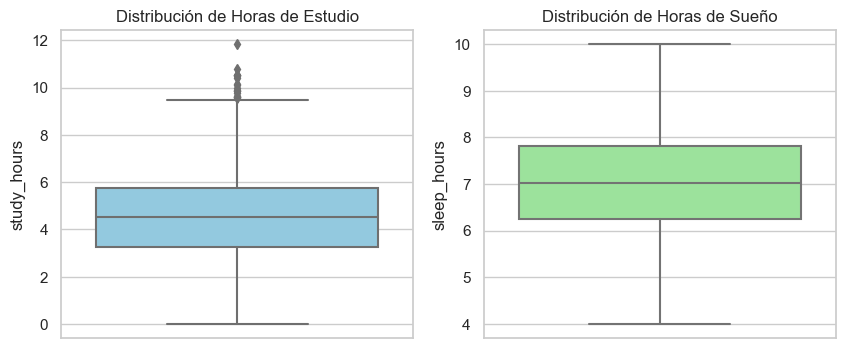

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df2, y='study_hours', ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Horas de Estudio')

sns.boxplot(data=df2, y='sleep_hours', ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Horas de Sueño')

plt.show()

In [11]:
#imputación de nulos con mediana para variables numericas
df2["study_hours"] = df2["study_hours"].fillna(df2["study_hours"].median())
df2["sleep_hours"] = df2["sleep_hours"].fillna(df2["sleep_hours"].median())

#Dropeamos nulos de gender y academic level, ya que no son muchos y no podemos inventar con aproximaciones
df2 = df2.dropna(subset=["gender", "academic_level"])

#Eliminamos el 1% más extremo
study_hours99 = np.percentile(df2["study_hours"], 99)
sleep_hours99 = np.percentile(df2["sleep_hours"], 99)

df2 = df2[(df2["study_hours"] <= study_hours99) &
          (df2["sleep_hours"] <= sleep_hours99)]

#Creamos variables dummy para las variables categóricas que no son binarias
df2 = pd.get_dummies(df2, columns=["gender", "academic_level"], drop_first=True, dtype=int)



---

# Pregunta 2

In [12]:
#creo dataframe con las variables que me importan
cmod= [
    "rinde_examen",
    "study_hours",
    "sleep_hours",
    "part_time_job",
    "upcoming_deadline",
    "gender_Male",
    "gender_Other",
    "academic_level_Postgraduate",
    "academic_level_Undergraduate"
]
df_modelos = df2[cmod].copy()

df_modelos = df_modelos.astype(float) #generaba error ya que upcoming deadline es Int64

ecuacion = """
rinde_examen ~ study_hours + sleep_hours + part_time_job + upcoming_deadline + gender_Male + gender_Other + academic_level_Postgraduate + 
academic_level_Undergraduate
"""

modelo_mco = smf.ols(formula=ecuacion, data=df_modelos).fit(cov_type="HC1")
print(modelo_mco.summary())

                            OLS Regression Results                            
Dep. Variable:           rinde_examen   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     40.33
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           1.33e-62
Time:                        16:29:35   Log-Likelihood:                -960.85
No. Observations:                4457   AIC:                             1940.
Df Residuals:                    4448   BIC:                             1997.
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## Conclusiones modelo de regresión lineal simple (MCO)

Nuestro modelo MCO con errores estándar robusto arroja un estadístico F de 1.33e-62, lo cual verifica que las variables explicativas seleccionadas influyen en conjunto en la probabilidad de que un alumno se presente a rendir el examen. Además, posee un R-cuadrado de 0.095, esto significa que logra explicar un 9.5% de la varianza de la variable a analizar (si un estudiante rinde o no el examen).

### Variables significativas
*Podemos notar que estas variables poseen un valor-p < 0.05*

- "study_hours": Tiene un valor-p de 0.000, con un coeficiente de 0.0462 que indica que por cada hora de estudio extra, hay un aumento de 4.62 puntos porcentuales en la probabilidad de que un estudiante rinda el examen.

- "sleep_hours": Tiene un valor-p de 0.000, con un coeficiente de 0.0375 que indica que por cada hora de sueño extra, hay un aumento de 3.75 puntos porcentuales en la probabilidad de rendir el examen por parte de un estudiante.

Podíamos esperar resultados de este estilo para estas variables, ya que, son hábitos que generalmente traen resultados positivos ante un examen.

- "part_time_job": Tiene un valor-p de 0.000, con un coeficiente de -0.0434 que indica que si un estudiante posee un trabajo part time, hay una disminución de 4.34 puntos porcentuales en la probabilidad de rendir el examen en comparación al que no tiene un trabajo part time.

Esto tiene sentido y relación a las variables antes vistas, ya que, probablemente invierten menos tiempo en estudiar, en dormir o ambas, lo cual puede generar inseguridad de los conocimientos y/o falta de preparación.

- "upcoming_deadline": Tiene un valor-p de 0.000, con un coeficiente de -0.0494 que indica que si un estudiante tiene otras responsabilidades que requieren una entrega o asistencia a rendir otro examen, hay una disminución de 4.94 puntos porcentuales en la probabilidad de rendir el examen por parte de un estudiante.

Esto se puede deber a razones de priorización de otras tareas, o mala organización del tiempo, que puede llevar a la falta de preparación para un examen, por lo que al tener otras responsabilidades, hay más probabilidad que decida no dar el examen, que si solo tiene este examen.

- "academic_level_Undergraduate" Tiene un valor-p de 0.002, con un coeficiente de 0.0344 que indica que un estudiante universitario de pregrado tiene 3.44 puntos porcentuales más de probabilidad de rendir el examen en comparación a los estudiantes de "high school" o colegio.

Esto probablemente se debe a la flexibilización que tienen los colegios por sobre universidades a la hora de realizar examenes atrasados, ya que, en el colegio a diferencia de la universidad se realizan estos, en horarios de clase o extraprogramáticos, los cuales el alumno puede acordar previamente con el profesor al tener mayor cercanía, quizás por que se ven un año entero a diferencia de la universidad que los profesores se ven con los alumnos en una asignatura 2 horas a la semana.

### Variables no significativas
*Podemos notar que estas variables poseen un valor-p > 0.05*

- "gender_Male" y "gender_Other": Estas son variables dummy que toman como base el género femenino, por lo tanto podemos notar la diferencia de probabilidad entre estas y nuestra variable base, pero considerando que tiene un valor-p de 0.451, independiente del coeficiente que tenga, este no es concluyente para nuestro análisis, por lo tanto, podemos considerar en principio que el género del estudiante no afecta significativamente en la probabilidad que tiene este de rendir un examen.

- "Academic_level_Postgraduate": Esta variable a diferencia de "academic_level_Undergraduate" no es significativa por muy poco, posee un valor-p de 0.06, pero al criterio de 5% de error permitido la consideramos no significativa, sin embargo, esta indicaba que un estudiante de una especialización post graduado tiene 2.13 puntos porcentuales más de probabilidad de rendir un examen que un estudiante de colegio.





# Pregunta 3

In [15]:
# Usamos exactamente la misma ecuación y datos que en el MCO para el modelo PROBIT
modelo_probit = smf.probit(formula=ecuacion, data=df_modelos).fit()
print(modelo_probit.summary())

# Calculamos e imprimimos los efectos marginales (dy/dx)
efectos_marginales_probit = modelo_probit.get_margeff()
print(efectos_marginales_probit.summary())


Optimization terminated successfully.
         Current function value: 0.302708
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:           rinde_examen   No. Observations:                 4457
Model:                         Probit   Df Residuals:                     4448
Method:                           MLE   Df Model:                            8
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.1377
Time:                        20:50:59   Log-Likelihood:                -1349.2
converged:                       True   LL-Null:                       -1564.7
Covariance Type:            nonrobust   LLR p-value:                 4.414e-88
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -1.1693      0.192     -6.084      0.000

Los resultados del modelo Probit son altamente consistentes con nuestra estimación por MCO y a su vez sumamente significativos debido al LLR p-value de 4.414e-88.

Ambos modelos identifican a las horas de estudio, sueño, poseer empleo part time y tener entregas pendientes como los principales motores de decisión del alumnado.

Podemos notar que los valores de los coeficientes en el modelo MCO y las magnitudes de los efectos marginales difieren muy poco en términos de puntos porcentuales, esto demuestra que nuestros resultados son robustos.

No obstante el Probit nos entrega mayor certeza teórica que el MCO, al forzar una distribución normal, evitamos la posibilidad de predecir probabilidades fuera del rango real.

Añadir que podemos concluir finalmente que "academic_level_Postgraduate" no es una variable significativa, por su valor-p de 0.111 a diferencia de antes (0.06), por lo que podemos concluir que no hay una diferencia concluyente entre los estudiantes de posgrado y los de colegio o highschool.

# Pregunta 4

In [16]:
# Estimamos el modelo Logit usando la misma ecuación
modelo_logit = smf.logit(formula=ecuacion, data=df_modelos).fit()
print(modelo_logit.summary())

# Calculamos e imprimimos los efectos marginales (dy/dx)
efectos_marginales_logit = modelo_logit.get_margeff()
print(efectos_marginales_logit.summary())


Optimization terminated successfully.
         Current function value: 0.301106
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           rinde_examen   No. Observations:                 4457
Model:                          Logit   Df Residuals:                     4448
Method:                           MLE   Df Model:                            8
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.1423
Time:                        21:14:16   Log-Likelihood:                -1342.0
converged:                       True   LL-Null:                       -1564.7
Covariance Type:            nonrobust   LLR p-value:                 3.858e-91
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -2.5019      0.361     -6.935      0.000

Nuevamente debido al LLR p-value de 3.858e-91 es altamente significativo el modelo explicativo.

Podemos notar que son robustamente significativas algunas variables ya que por ejemplo en el modelo MCO el coeficiente y en el modelo Logit el efecto marginal de la variable "upcoming_deadline" posee el mismo valor (-0.0494).

El modelo Logit asume una distribución logística de los errores y corrobora lo hallado en el MCO y el Probit, tal que todas las variables significativas mantuvieron sus niveles de significancia, con valores de coeficientes y efectos marginales muy similares.

# Pregunta 5

La conclusión general es que los resultados son empíricamente consistentes. Los tres modelos van en la misma dirección y con magnitudes muy similares. Estudiar y dormir suma puntos porcentuales; tener trabajo y deadlines los resta. El género no influye de ninguna manera y el nivel académico solo influye significativamente en los estudiantes de pregrado.

La diferencia entre los valores de los distintos modelos no es significativa, pero esta se debe a que el MCO simplemente dibuja una línea recta infinita, por lo que asume que el efecto de una hora extra de sueño es la misma para el que duerme 1 hora y para el que duerme 12, y eso no es asi. El modelo Probit y Logit solucionan esto curvando la línea en forma de S, obligando a la predicción a estar siempre entre 0 y 1. La pequeña diferencia entre estos últimos modelos mencionados es que la campana logística en el modelo Logit tiene colas un poco más gordas, por lo que trata los extremos con más indulgencia.

El modelo más adecuado sería el Logit debido a que su distribución de colas más pesadas provee mayor robustez general ante casos extremos impredecibles de los estudiantes que el modelo Probit.

Las variables que resultaron ser robustamente significativas fueron: "study_hours", "sleep_hours", "part_time_job", "upcoming_deadline" y "academic_level_Undergraduate", ya que se mantuvieron significativas en todos los modelos de regresión.


# Pregunta 6

In [19]:
# Filtramos los datos

df_poisson = df2[df2["rinde_examen"] == 1].copy()

# Seleccionamos las columnas y las pasamos a float para evitar errores
columnas_poisson = [
    "exam_score", 
    "study_hours", "sleep_hours", "part_time_job", "upcoming_deadline", 
    "gender_Male", "gender_Other", "academic_level_Postgraduate", "academic_level_Undergraduate"
]
df_poisson = df_poisson[columnas_poisson].astype(float)

ecuacion_poisson = """
exam_score ~ study_hours + sleep_hours + part_time_job + upcoming_deadline + gender_Male + gender_Other + academic_level_Postgraduate + academic_level_Undergraduate
"""

# Estimamos el modelo Poisson
modelo_poisson = smf.poisson(formula=ecuacion_poisson, data=df_poisson).fit()
print(modelo_poisson.summary())

# Generamos las predicciones matemáticas (Lambda). 
# comprobar sobredispersión después.
df_poisson['ppredictions'] = modelo_poisson.predict(df_poisson).astype(float)

# Extraemos los coeficientes originales del modelo
coeficientes_poisson = modelo_poisson.params

# Creamos un DataFrame para mostrar los resultados de forma ordenada
# Calculamos e^coef y también el porcentaje exacto de cambio
tabla_interpretacion = pd.DataFrame({
    'Coef. Original': coeficientes_poisson,
    'Factor Exponencial (e^coef)': np.exp(coeficientes_poisson),
    'Cambio Porcentual Exacto (%)': (np.exp(coeficientes_poisson) - 1) * 100
})

# Imprimimos el resultado redondeado a 2 decimales para que sea legible
print("--- Interpretación Real de Coeficientes Poisson sobre la Nota Final ---")
print(tabla_interpretacion.round(2))



Optimization terminated successfully.
         Current function value: 4.623167
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:             exam_score   No. Observations:                 3957
Model:                        Poisson   Df Residuals:                     3948
Method:                           MLE   Df Model:                            8
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.1695
Time:                        22:58:28   Log-Likelihood:                -18294.
converged:                       True   LL-Null:                       -22028.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        1.6205      0.027     59.625      0.000

Después de aplicar la función exponencial a los coeficientes que nos entrega el modelo Poisson, obtenemos realmente la magnitud de las variaciones. Las cuales curiosamente aumentan bastante al haber cambiado nuestra variable dependiente ("exam_score").

Recalcar que seguimos con las mismas variables significativas a diferencia de una. "academic_level_Undergraduate" era una variable significativa en nuestros anteriores modelos, pero ahora no, a diferencia de "academic_level_Postgraduate" que ahora si es significativa, con un coeficiente no muy grande pero significativo.

Podemos notar que por cada hora de sueño extra, la calificación aumenta un 16.01%, una hora extra de sueño aumenta un 12.7%, tener trabajo part time disminuye un 13.79% las calificaciones en comparación al que no tiene trabajo, tener una entrega pendiente con fecha límite disminuye drásticamente la calificación en un 20.61% en comparación al que solo tiene que rendir este examen y la nueva variable significativa dentro de este modelo; los estudiantes de posgrado tienen un 1.94% de calificaciones superiores en comparación a los estudiantes de colegio o highschool.

# Pregunta 7

In [ ]:
# Eliminamos cualquier nulo para la prueba
df_poisson = df_poisson.dropna()

# Creamos la variable auxiliar basándonos en la fórmula estadística:
aux = ((df_poisson['exam_score'] - df_poisson['ppredictions'])**2 - df_poisson['ppredictions']) / df_poisson['ppredictions']

# Corremos la regresión OLS sin constante, sólo usando nuestra variable auxiliar y la predicción
prueba_alpha = sm.OLS(aux, df_poisson['ppredictions']).fit()

# Imprimimos el modelo
print(prueba_alpha.summary())


                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.236
Model:                            OLS   Adj. R-squared (uncentered):              0.236
Method:                 Least Squares   F-statistic:                              1224.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):                   7.20e-234
Time:                        23:25:12   Log-Likelihood:                         -12364.
No. Observations:                3957   AIC:                                  2.473e+04
Df Residuals:                    3956   BIC:                                  2.474e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

Si existe sobredispersión y esto se debe a que ya no estamos calculando la probabilidad de que rinda el examen o no, si no, que estamos intentando predecir la nota exacta de un estudiante, que puede no estar explicada necesariamente por estas variables, ya que no consideramos nervios, ansiedad, genética, etc, lo que hace hace que nuestro modelo se aleje de la predicción esperada.
El posible valor óptimo para el alpha para el modelo de binomial negativa que realizaremos es de 0.1439.

# Pregunta 8

In [24]:
alpha_optimo = 0.1439

# Estimamos el modelo Binomial Negativo. 
modelo_nbin = smf.glm(
    formula=ecuacion_poisson, 
    data=df_poisson, 
    family=sm.families.NegativeBinomial(alpha=alpha_optimo)
).fit()

print(modelo_nbin.summary())

# Hacemos la magia del porcentaje para que lo puedas interpretar fácilmente
coeficientes_nbin = modelo_nbin.params
tabla_nbin = pd.DataFrame({
    'Coef. Original': coeficientes_nbin,
    'Cambio Porcentual Exacto (%)': (np.exp(coeficientes_nbin) - 1) * 100
})

print("\n--- Interpretación de Coeficientes: Binomial Negativo ---")
print(tabla_nbin.round(2))

                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 3957
Model:                            GLM   Df Residuals:                     3948
Model Family:        NegativeBinomial   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14515.
Date:                Wed, 22 Apr 2026   Deviance:                       5491.0
Time:                        10:41:02   Pearson chi2:                 4.61e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3885
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

Para responder a la predicción de calificación con la varianza corregida, utilizamos el modelo Binomial Negativo incluyendo exactamente las mismas variables del modelo base. Los resultados nos indican los impactos porcentuales en la nota de manera mucho más rigurosa:

Una hora de estudio aumenta la nota esperada en un +16.48%.

Una hora de sueño extra aumenta la nota esperada en un +13.30%.

Tener trabajo (part-time) destruye la calificación, restando un significativo -13.91%.

Tener otros entregables paralelos tiene un castigo aún mayor, restando un -21.34% a la nota final.

Además, se evidencia estadísticamente que atributos como el género o nivel académico del estudiante no tienen significancia real para predecir las calificaciones finales bajo este modelo más robusto.

# Pregunta 9

**1. Diferencias entre modelos (6, 7 y 8)**

El modelo Poisson nos indicó equivocadamente que tener un nivel de posgrado era significativo frente a las notas. Esto ocurrió porque Poisson asume que la varianza de los datos es igual a su media. Sin embargo, nuestro test  demostró empíricamente que existe una gran sobredispersión, es decir, el mundo real de las calificaciones es caótico y nuestra predicción tiene mayores márgenes de error. Al usar el modelo Binomial Negativo (Pregunta 8), obligamos a la matemática a considerar esa sobredispersión, se corrigieron los errores estándar, y se descubrió la verdad empírica: ser de posgrado realmente no influye en las notas.

**2. ¿Cuál es el modelo más adecuado?**

El ganador definitivo para este ecosistema es el Binomial Negativo. Es el único que se adapta al desorden real y humano de las calificaciones de los alumnos al controlar la sobredispersión, entregándonos conclusiones limpias, estadísticamente rigurosas y sin falsos positivos. Todo esto mientras previene matemáticamente la predicción de resultados irreales.

**3. Variables robustas**

A través de absolutamente todos los modelos matemáticos testeados, las únicas cuatro variables que irrefutablemente afectan el desempeño de un estudiante, sobreviviendo incluso a la inflación de errores de la Binomial Negativa, son:

* **Efectos Positivos:** "study_hours" y "sleep_hours".
* **Efectos Negativos:** "part_time_job" y "upcoming_deadline".

Variables demográficas como el género o nivel educacional demostraron ser irrelevantes frente a estos cuatro grandes factores de esfuerzo y manejo del tiempo.
